In [1]:
from functions.clustering_functions import clustering_2_communities, ARI_fscore
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
from functions.plots import plot_ARI_f1
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic_fit_matrix, ask_yes_no, ask_input
from functions.cosmograph_functions import visualize_graph_paysim

In [2]:
save_fig = False

First pass: Identifying users and fraud accounts...
Found 111 unique users
Found 24 fraud accounts
Second pass: Processing transactions and building matrices...


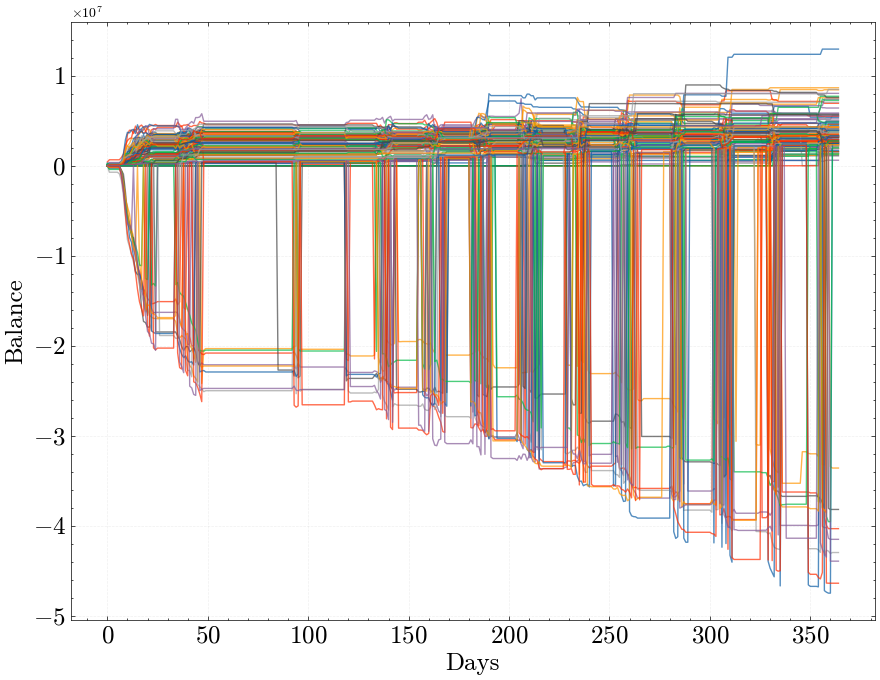

     B4515557242  C0195795724  C0296621297  C0457412292  C0604845515  \
0           0.00     35284.39    151431.92        58.79        53.34   
1           0.00     90665.17    225736.73        58.79        53.34   
2           0.00     90665.17    225736.73        58.79        53.34   
3           0.00     90665.17    225736.73        58.79        53.34   
4           0.00     90665.17    225736.73        58.79        53.34   
..           ...          ...          ...          ...          ...   
360    939150.89   3649972.98   2559521.93   3634953.51   4151361.31   
361    939150.89   3649972.98   2559521.93   3634953.51   4151361.31   
362    939150.89   3649972.98   2559521.93   3634953.51   4151361.31   
363    939150.89   3649972.98   2559521.93   3634953.51   4151361.31   
364    939150.89   3649972.98   2559521.93   3634953.51   4151361.31   

     C0606810760  C0692194787  C0867198867  C0975690911  C1000631618  ...  \
0          30.79        51.74        72.49     15326.73   

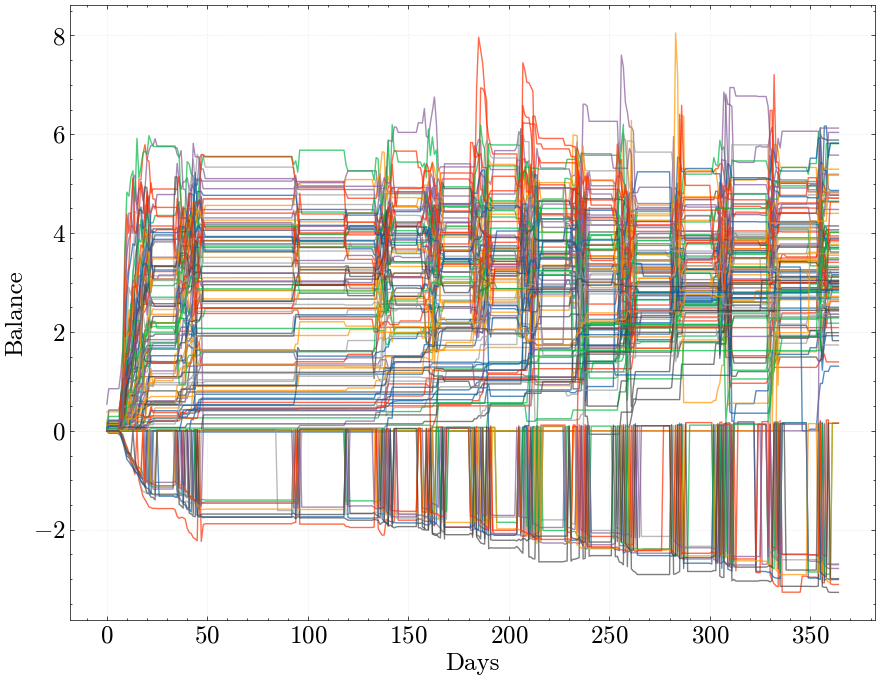

          0         1         2         3         4         5         6    \
0    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1    0.021057  0.054107  0.054107  0.054107  0.054107  0.054107  0.054107   
2    0.145583  0.217017  0.217017  0.217017  0.217017  0.217017  0.217017   
3    0.000063  0.000063  0.000063  0.000063  0.000063  0.000063  0.000063   
4    0.000060  0.000060  0.000060  0.000060  0.000060  0.000060  0.000060   
..        ...       ...       ...       ...       ...       ...       ...   
106  0.000000 -0.018583 -0.018583 -0.018583 -0.018583 -0.018583 -0.018583   
107  0.000000 -0.031739 -0.031739 -0.031739 -0.031739 -0.031739 -0.031739   
108  0.000000 -0.013218 -0.013218 -0.013218 -0.013218 -0.013218 -0.013218   
109  0.000000 -0.007867 -0.007867 -0.007861 -0.007861 -0.007861 -0.010502   
110  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

          7         8         9    ...       355       356       357  \
0  

In [3]:
user_input = ask_yes_no("\nDo you want to load data?")

name = 'PAYSIM'
if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)
    
else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(save_fig)
    
results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save, times_dict = run_squic_fit_matrix(Y_norm, knn_matrix, results_squic, name, dimension)
    
else:
    results_squic, squic_method, save, times_dict = run_squic_fit(Y_norm, results_squic, name, dimension)

In [4]:
from functions.cosmograph_functions import cosmograph_from_theta
widget_dict = {}
for rho, model_fit in results_squic[squic_method].items():
    widget_dict = cosmograph_from_theta(model_fit, rho, widget_dict)


dimension_lambda = {
    "100" : 0.3,
    "1K" : 0.95,
    "10K" : 0.999,
    "100K" : 0.99992
}


widget_dict[dimension_lambda[dimension]]

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…


for rho 0.6 graph is connected: False
Computing spectral clustering for rho 0.6...
For rho 0.6 takes 0.01 seconds

for rho 0.5 graph is connected: False
Computing spectral clustering for rho 0.5...
For rho 0.5 takes 0.0 seconds

for rho 0.4 graph is connected: False
Computing spectral clustering for rho 0.4...
For rho 0.4 takes 0.0 seconds

for rho 0.3 graph is connected: False
Computing spectral clustering for rho 0.3...
For rho 0.3 takes 0.0 seconds

for rho 0.2 graph is connected: True
Computing spectral clustering for rho 0.2...
For rho 0.2 takes 0.0 seconds

for rho 0.1 graph is connected: True
Computing spectral clustering for rho 0.1...
For rho 0.1 takes 0.0 seconds
for lambda = 0.6 : {'Spectral': {'nCluster': 2, 'ARI': 0.01, 'f1': 0.55}}
for lambda = 0.5 : {'Spectral': {'nCluster': 2, 'ARI': 1.0, 'f1': 1.0}}
for lambda = 0.4 : {'Spectral': {'nCluster': 2, 'ARI': 1.0, 'f1': 1.0}}
for lambda = 0.3 : {'Spectral': {'nCluster': 2, 'ARI': 0.93, 'f1': 0.99}}
for lambda = 0.2 : {'Spec

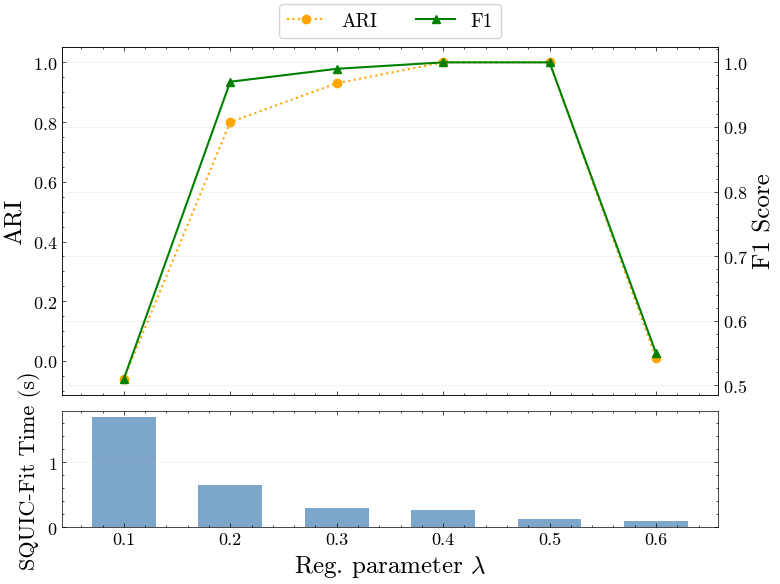

In [5]:
# Results
dict_cluster = clustering_2_communities(results_squic, squic_method, dimension)

metrics = ARI_fscore(dict_cluster, results_squic, account_prop)

for _, data in metrics.items():
    for rho, results in data.items():
        print(f"for lambda = {rho} : {results}")

plot_ARI_f1(metrics, squic_method, dimension, times_dict, save=save)

In [6]:
graph = visualize_graph_paysim(results_squic, squic_method, dict_cluster, account_prop)
graph[dimension_lambda[dimension]]

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…